# Proyecto Final: Aprendizaje de Máquinas Supervisado — Inteligencia Artificial 2026-I



---

## Descripción del Problema


El presente proyecto se enfoca en la aplicación de técnicas de aprendizaje automático para la clasificación de tratamientos dentro del contexto de la medicina tradicional Ayurveda.
El objetivo principal consiste en desarrollar un modelo capaz de predecir la variable “Treatment Type”, que representa el tipo de intervención terapéutica recomendada a partir de información clínica, sintomática y categórica de los pacientes.
Este problema presenta un nivel significativo de complejidad, ya que la variable objetivo contiene múltiples combinaciones posibles de tratamientos, y diferentes conjuntos de síntomas pueden estar asociados a más de una categoría terapéutica. Esto introduce ambigüedad en el proceso de clasificación y dificulta la separación clara entre clases.
A lo largo del proyecto, se implementan distintas estrategias de preprocesamiento, transformación de datos y modelado, con el fin de mejorar la capacidad predictiva y evaluar el comportamiento de distintos algoritmos frente a la naturaleza compleja del dataset.

# Librerias utilizadas




In [1]:
import pandas as pd
import numpy as np
import re
import string
import time
import warnings

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import OneHotEncoder, LabelEncoder
from sklearn.decomposition import TruncatedSVD
from scipy.sparse import hstack

from sklearn.model_selection import train_test_split, GridSearchCV

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.titlesize'] = 13

print("✔ Librerías cargadas correctamente")

✔ Librerías cargadas correctamente


### Carga del data set

In [2]:


df = pd.read_csv('ayurveda_healthcare_dataset.csv')  # o el archivo original que estés usando

print("✔ Dataset cargado correctamente")
df.head()

✔ Dataset cargado correctamente


,ID,Problem,Symptoms,Remedies,Medicines,Source,Dosha Type,Body System,Chronic/Acute,Treatment Type,...,Preventive Advice,Seasonal Suitability,Gender/Age Relevance,Confidence,Classical Texts,Modern Evidence,Institutional Endorsements,WHO Strategy Reference,Authentication Notes,Auth_Score
0,1,Jaundice (Kamala) - variant 9,loss of appetite; bloating; belching; abdomina...,Jeera-coriander-boiled water (sip warm) after ...,"Shatavari, Triphala, Ashwagandha","Áyurveda Encyclopedia - Ch.15, p.405",Pitta,Digestive,Chronic,Lifestyle,...,Maintain regular diet and routine; balance the...,All seasons,All,0.87,Charaka Samhita; Sushruta Samhita; Ashtanga Hr...,Systematic reviews and PubMed-indexed studies ...,Ministry of AYUSH (Government of India); WHO g...,WHO Traditional Medicine Strategy 2014–2023 (WHO),Primary source: 'The Ayurveda Encyclopedia' (S...,0.90
1,2,Migraines,anxiety; insomnia; excessive worrying; dizziness,Practice gentle breathing (Anulom Vilom/altern...,"Haritaki, Licorice (Yashtimadhu)","Áyurveda Encyclopedia - Ch.16, p.405",Vata-Pitta,Nervous,Acute,Panchakarma,...,Maintain regular diet and routine; balance the...,Summer (Pitta-prone),All,0.74,Charaka Samhita; Sushruta Samhita; Ashtanga Hr...,Systematic reviews and PubMed-indexed studies ...,Ministry of AYUSH (Government of India); WHO g...,WHO Traditional Medicine Strategy 2014–2023 (WHO),Primary source: 'The Ayurveda Encyclopedia' (S...,0.80
2,3,Parkinson-like symptoms,anxiety; insomnia; excessive worrying; dizziness,Ashwagandha milk (if appropriate) as a tonic f...,"Turmeric, Kutki","Áyurveda Encyclopedia - Ch.18, p.510",Vata-Kapha,Nervous,Chronic,Surgery (rare),...,Maintain regular diet and routine; balance the...,Monsoon (Ama-prone),All,0.63,Charaka Samhita; Sushruta Samhita; Ashtanga Hr...,Systematic reviews and PubMed-indexed studies ...,Ministry of AYUSH (Government of India); WHO g...,WHO Traditional Medicine Strategy 2014–2023 (WHO),Primary source: 'The Ayurveda Encyclopedia' (S...,0.84
3,4,Hiccup (Hikka),runny nose; sneezing; sinus pressure; post-nas...,Warm ginger-tulsi-honey decoction thrice daily...,"Ginger, Khadira","Áyurveda Encyclopedia - Ch.19, p.391",Vata,Respiratory,Acute,Topical,...,Maintain regular diet and routine; balance the...,Summer (Pitta-prone),All,0.86,Charaka Samhita; Sushruta Samhita; Ashtanga Hr...,Systematic reviews and PubMed-indexed studies ...,Ministry of AYUSH (Government of India); WHO g...,WHO Traditional Medicine Strategy 2014–2023 (WHO),Primary source: 'The Ayurveda Encyclopedia' (S...,0.83
4,5,Indigestion (Ajeerna),nausea; vomiting; sour belching; heartburn; ac...,Fresh ginger and lemon water before meals; avo...,"Licorice (Yashtimadhu), Ginger","Áyurveda Encyclopedia - Ch.25, p.492",Pitta,Digestive,Acute,Panchakarma,...,Maintain regular diet and routine; balance the...,All seasons,All,0.61,Charaka Samhita; Sushruta Samhita; Ashtanga Hr...,Systematic reviews and PubMed-indexed studies ...,Ministry of AYUSH (Government of India); WHO g...,WHO Traditional Medicine Strategy 2014–2023 (WHO),Primary source: 'The Ayurveda Encyclopedia' (S...,0.91


### **2. Inspección del Dataset**

Tras la carga del archivo y la aplicación de funciones básicas de la librería *Pandas* (`head()`, `shape`, `dtypes`, `isnull()`), se realizó una inspección inicial para comprender la estructura y características del dataset.

**Volumen de datos:**  
El dataset está compuesto por **10,000 registros** y **21 variables** en su estado original.

**Proceso de reducción inicial:**  
Se eliminaron múltiples columnas consideradas irrelevantes o con bajo valor predictivo, tales como:

- ID  
- Source  
- Confidence  
- Auth_Score  
- Preventive Advice  
- Classical Texts  
- Modern Evidence  
- Institutional Endorsements  
- WHO Strategy Reference  
- Authentication Notes  
- Remedies  
- Medicines  

Tras esta limpieza, el dataset quedó reducido a **9 variables principales**, facilitando su manejo y análisis.

**Columnas finales analizadas:**

- Problem  
- Symptoms  
- Dosha Type  
- Body System  
- Chronic/Acute  
- Treatment Type  
- Contraindications  
- Seasonal Suitability  
- Gender/Age Relevance  

**Tipos de variables:**  
La totalidad de las variables corresponde al tipo **objeto (texto)**, lo que indica la necesidad de aplicar técnicas de codificación y procesamiento de lenguaje natural para su uso en modelos de aprendizaje automático.

**Variable objetivo:**  
Se seleccionó la columna **“Treatment Type”** como variable objetivo del modelo, la cual inicialmente contenía múltiples combinaciones de tratamientos, lo que representaba un reto adicional en términos de modelado.


In [4]:
# INSPECCIÓN INICIAL DEL DATASET

# tamaño
print(f'Dimensiones del dataset: {df.shape[0]} registros x {df.shape[1]} columnas')

# Columnas 
print("\nColumnas originales:")
print(list(df.columns))

# Tipos de datos
print("\nTipos de datos:")
print(df.dtypes)

# Valores nulos
print("\nValores nulos por columna:")
print(df.isnull().sum())

# Vista general
df.head() # type: ignore


Dimensiones del dataset: 10000 registros x 21 columnas

Columnas originales:
['ID', 'Problem', 'Symptoms', 'Remedies', 'Medicines', 'Source', 'Dosha Type', 'Body System', 'Chronic/Acute', 'Treatment Type', 'Contraindications', 'Preventive Advice', 'Seasonal Suitability', 'Gender/Age Relevance', 'Confidence', 'Classical Texts', 'Modern Evidence', 'Institutional Endorsements', 'WHO Strategy Reference', 'Authentication Notes', 'Auth_Score']

Tipos de datos:
ID                              int64
Problem                           str
Symptoms                          str
Remedies                          str
Medicines                         str
Source                            str
Dosha Type                        str
Body System                       str
Chronic/Acute                     str
Treatment Type                    str
Contraindications                 str
Preventive Advice                 str
Seasonal Suitability              str
Gender/Age Relevance              str
Confidenc

,ID,Problem,Symptoms,Remedies,Medicines,Source,Dosha Type,Body System,Chronic/Acute,Treatment Type,...,Preventive Advice,Seasonal Suitability,Gender/Age Relevance,Confidence,Classical Texts,Modern Evidence,Institutional Endorsements,WHO Strategy Reference,Authentication Notes,Auth_Score
0,1,Jaundice (Kamala) - variant 9,loss of appetite; bloating; belching; abdomina...,Jeera-coriander-boiled water (sip warm) after ...,"Shatavari, Triphala, Ashwagandha","Áyurveda Encyclopedia - Ch.15, p.405",Pitta,Digestive,Chronic,Lifestyle,...,Maintain regular diet and routine; balance the...,All seasons,All,0.87,Charaka Samhita; Sushruta Samhita; Ashtanga Hr...,Systematic reviews and PubMed-indexed studies ...,Ministry of AYUSH (Government of India); WHO g...,WHO Traditional Medicine Strategy 2014–2023 (WHO),Primary source: 'The Ayurveda Encyclopedia' (S...,0.90
1,2,Migraines,anxiety; insomnia; excessive worrying; dizziness,Practice gentle breathing (Anulom Vilom/altern...,"Haritaki, Licorice (Yashtimadhu)","Áyurveda Encyclopedia - Ch.16, p.405",Vata-Pitta,Nervous,Acute,Panchakarma,...,Maintain regular diet and routine; balance the...,Summer (Pitta-prone),All,0.74,Charaka Samhita; Sushruta Samhita; Ashtanga Hr...,Systematic reviews and PubMed-indexed studies ...,Ministry of AYUSH (Government of India); WHO g...,WHO Traditional Medicine Strategy 2014–2023 (WHO),Primary source: 'The Ayurveda Encyclopedia' (S...,0.80
2,3,Parkinson-like symptoms,anxiety; insomnia; excessive worrying; dizziness,Ashwagandha milk (if appropriate) as a tonic f...,"Turmeric, Kutki","Áyurveda Encyclopedia - Ch.18, p.510",Vata-Kapha,Nervous,Chronic,Surgery (rare),...,Maintain regular diet and routine; balance the...,Monsoon (Ama-prone),All,0.63,Charaka Samhita; Sushruta Samhita; Ashtanga Hr...,Systematic reviews and PubMed-indexed studies ...,Ministry of AYUSH (Government of India); WHO g...,WHO Traditional Medicine Strategy 2014–2023 (WHO),Primary source: 'The Ayurveda Encyclopedia' (S...,0.84
3,4,Hiccup (Hikka),runny nose; sneezing; sinus pressure; post-nas...,Warm ginger-tulsi-honey decoction thrice daily...,"Ginger, Khadira","Áyurveda Encyclopedia - Ch.19, p.391",Vata,Respiratory,Acute,Topical,...,Maintain regular diet and routine; balance the...,Summer (Pitta-prone),All,0.86,Charaka Samhita; Sushruta Samhita; Ashtanga Hr...,Systematic reviews and PubMed-indexed studies ...,Ministry of AYUSH (Government of India); WHO g...,WHO Traditional Medicine Strategy 2014–2023 (WHO),Primary source: 'The Ayurveda Encyclopedia' (S...,0.83
4,5,Indigestion (Ajeerna),nausea; vomiting; sour belching; heartburn; ac...,Fresh ginger and lemon water before meals; avo...,"Licorice (Yashtimadhu), Ginger","Áyurveda Encyclopedia - Ch.25, p.492",Pitta,Digestive,Acute,Panchakarma,...,Maintain regular diet and routine; balance the...,All seasons,All,0.61,Charaka Samhita; Sushruta Samhita; Ashtanga Hr...,Systematic reviews and PubMed-indexed studies ...,Ministry of AYUSH (Government of India); WHO g...,WHO Traditional Medicine Strategy 2014–2023 (WHO),Primary source: 'The Ayurveda Encyclopedia' (S...,0.91



#  Preprocesamiento de Datos y Feature Engineering



### **3. Calidad de los Datos y Limpieza**

Una vez realizada la inspección inicial del dataset, se procedió a evaluar la calidad de los datos con el objetivo de identificar posibles problemas que pudieran afectar el desempeño de los modelos de aprendizaje automático.

#### **3.1 Valores Faltantes**

Se detectó la presencia de valores nulos en la columna **Contraindications**, con un total de **2,981 registros faltantes**, lo que representa aproximadamente un 29.8% del dataset.

Dado el contexto del problema, se interpreta que la ausencia de información en esta variable indica que no existen contraindicaciones registradas para ese caso. Por esta razón, se decidió imputar estos valores con la categoría explícita **"None"**, evitando la pérdida de información que implicaría eliminar registros.

#### **3.2 Registros Duplicados**

Se realizó una verificación de duplicados en el dataset, confirmando que no existen registros repetidos, lo cual garantiza la integridad de los datos.

#### **3.3 Eliminación de Variables Irrelevantes**

Durante la inspección inicial se identificaron múltiples variables que no aportaban información relevante para el proceso de clasificación, ya sea por ser constantes o por no tener relación directa con el problema planteado. Estas variables fueron eliminadas para reducir ruido en los datos y mejorar la eficiencia del modelo.

#### **3.4 Consideraciones Generales**

El proceso de limpieza aplicado permitió obtener un dataset más consistente y adecuado para el modelado, garantizando que:

- No existan valores faltantes sin tratar  
- Las variables utilizadas aporten valor predictivo  
- Se mantenga la mayor cantidad de información posible  



In [43]:
df_cleaned = df.copy()

# Columnas a eliminar
cols_drop = [
    'ID',
    'Source',
    'Confidence',
    'Auth_Score',
    'Preventive Advice',
    'Classical Texts',
    'Modern Evidence',
    'Institutional Endorsements',
    'WHO Strategy Reference',
    'Authentication Notes',
    'Remedies',
    'Medicines'
]

# Eliminar columnas
df_cleaned = df_cleaned.drop(columns=cols_drop, errors='ignore')

# se rellenan los datos nulos

df_cleaned['Contraindications'] = df_cleaned['Contraindications'].fillna('None')

# VERIFICACIÓN

print("✔ df_cleaned creado correctamente")
print(f"Dimensiones: {df_cleaned.shape}")
print("\nColumnas finales:")
print(list(df_cleaned.columns))


# Vista rápida
df_cleaned.head()

✔ df_cleaned creado correctamente
Dimensiones: (10000, 9)

Columnas finales:
['Problem', 'Symptoms', 'Dosha Type', 'Body System', 'Chronic/Acute', 'Treatment Type', 'Contraindications', 'Seasonal Suitability', 'Gender/Age Relevance']


,Problem,Symptoms,Dosha Type,Body System,Chronic/Acute,Treatment Type,Contraindications,Seasonal Suitability,Gender/Age Relevance
0,Jaundice (Kamala) - variant 9,loss of appetite; bloating; belching; abdomina...,Pitta,Digestive,Chronic,Lifestyle,Avoid suppression of natural urges,All seasons,All
1,Migraines,anxiety; insomnia; excessive worrying; dizziness,Vata-Pitta,Nervous,Acute,Panchakarma,None,Summer (Pitta-prone),All
2,Parkinson-like symptoms,anxiety; insomnia; excessive worrying; dizziness,Vata-Kapha,Nervous,Chronic,Surgery (rare),Avoid incompatible food combinations,Monsoon (Ama-prone),All
3,Hiccup (Hikka),runny nose; sneezing; sinus pressure; post-nas...,Vata,Respiratory,Acute,Topical,Avoid alcohol and excess salt,Summer (Pitta-prone),All
4,Indigestion (Ajeerna),nausea; vomiting; sour belching; heartburn; ac...,Pitta,Digestive,Acute,Panchakarma,Avoid incompatible food combinations,All seasons,All


### **4. Análisis de Distribución (EDA)**

Con el objetivo de comprender el comportamiento de la variable objetivo, se realizó un análisis exploratorio de la distribución de la columna **“Treatment Type”**.

#### **4.1 Distribución de Clases**

El análisis inicial muestra que la variable objetivo presenta una alta diversidad de categorías, muchas de ellas con nombres compuestos o combinaciones de tratamientos. Esto genera un problema de clasificación multiclase con un elevado número de clases y con alta similitud entre ellas.

Al visualizar la frecuencia de cada categoría, se observa que:

- Existen clases con una alta cantidad de registros  
- Otras clases presentan menor frecuencia  
- Se evidencia un nivel moderado de desbalance entre categorías  

#### **4.2 Interpretación del Comportamiento**

La distribución observada indica que el problema no es tan simple, ya que:

- Diferentes instancias pueden compartir características similares pero pertenecen a clases distintas  
- Algunas clases representan combinaciones de tratamientos, lo que aumenta la complejidad del modelo  
- Existe solapamiento entre categorías, dificultando la separación clara entre clases  

#### **4.3 Implicaciones para el Modelado**

Este comportamiento sugiere que:

- Los modelos lineales podrían presentar dificultades para separar las clases  
- Es necesario aplicar estrategias adicionales para mejorar la representatividad de los datos  
- Podría ser necesario reducir la complejidad de la variable objetivo para facilitar el aprendizaje  



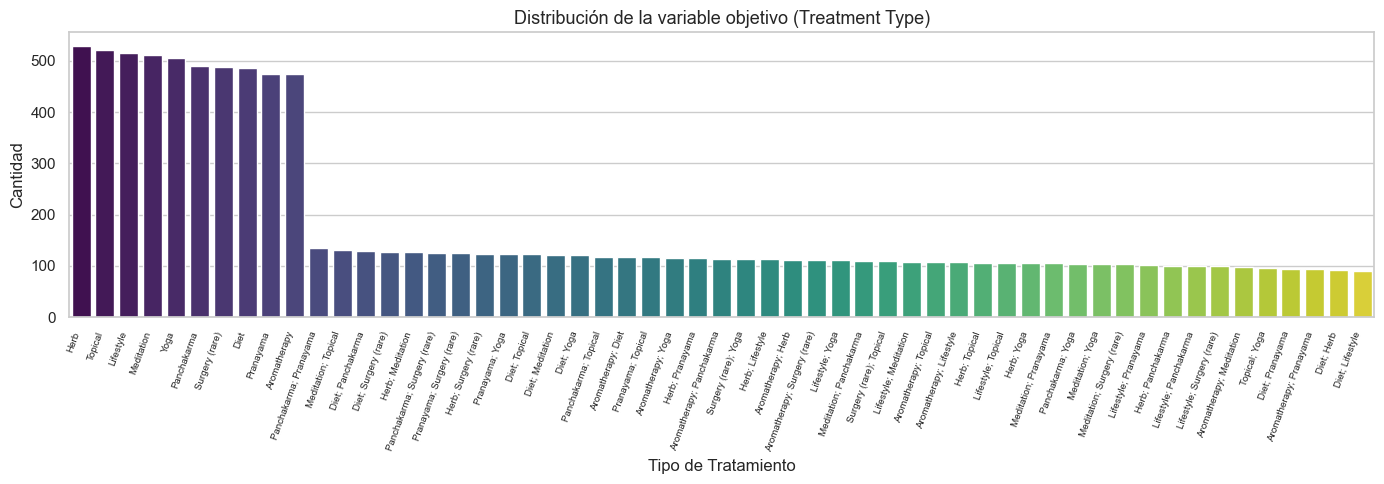

Treatment Type
Herb                            529
Topical                         521
Lifestyle                       515
Meditation                      511
Yoga                            506
Panchakarma                     489
Surgery (rare)                  488
Diet                            486
Pranayama                       475
Aromatherapy                    474
Panchakarma; Pranayama          134
Meditation; Topical             131
Diet; Panchakarma               130
Diet; Surgery (rare)            127
Herb; Meditation                127
Panchakarma; Surgery (rare)     126
Pranayama; Surgery (rare)       126
Herb; Surgery (rare)            123
Pranayama; Yoga                 123
Diet; Topical                   123
Diet; Meditation                122
Diet; Yoga                      121
Panchakarma; Topical            117
Aromatherapy; Diet              117
Pranayama; Topical              117
Aromatherapy; Yoga              116
Herb; Pranayama                 115
Aromatherapy;

In [44]:
# DISTRIBUCIÓN DE VARIABLE OBJETIVO

import matplotlib.pyplot as plt
import seaborn as sns

class_counts = df_cleaned['Treatment Type'].value_counts()

plt.figure(figsize=(14,5))
sns.barplot(x=class_counts.index, y=class_counts.values, palette='viridis')

plt.title('Distribución de la variable objetivo (Treatment Type)')
plt.xlabel('Tipo de Tratamiento')
plt.ylabel('Cantidad')

plt.xticks(rotation=70, ha='right', fontsize=7)

plt.tight_layout()
plt.show()

# Mostrar valores numéricos
print(class_counts)

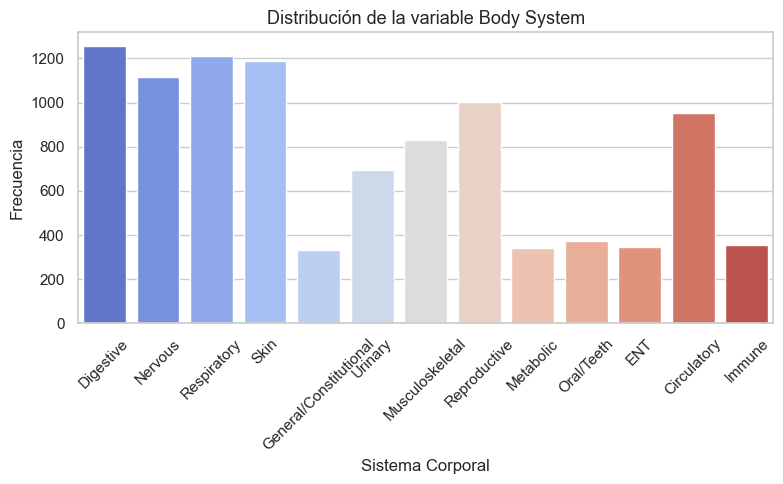

In [45]:
# DISTRIBUCIÓN BODY SYSTEM

plt.figure(figsize=(8,5))
sns.countplot(data=df_cleaned, x='Body System', palette='coolwarm')

plt.title('Distribución de la variable Body System')
plt.xlabel('Sistema Corporal')
plt.ylabel('Frecuencia')

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

La variable Body System presenta una distribución no uniforme, indicando que algunos sistemas corporales están más representados que otros. Esto puede influir en el aprendizaje del modelo.


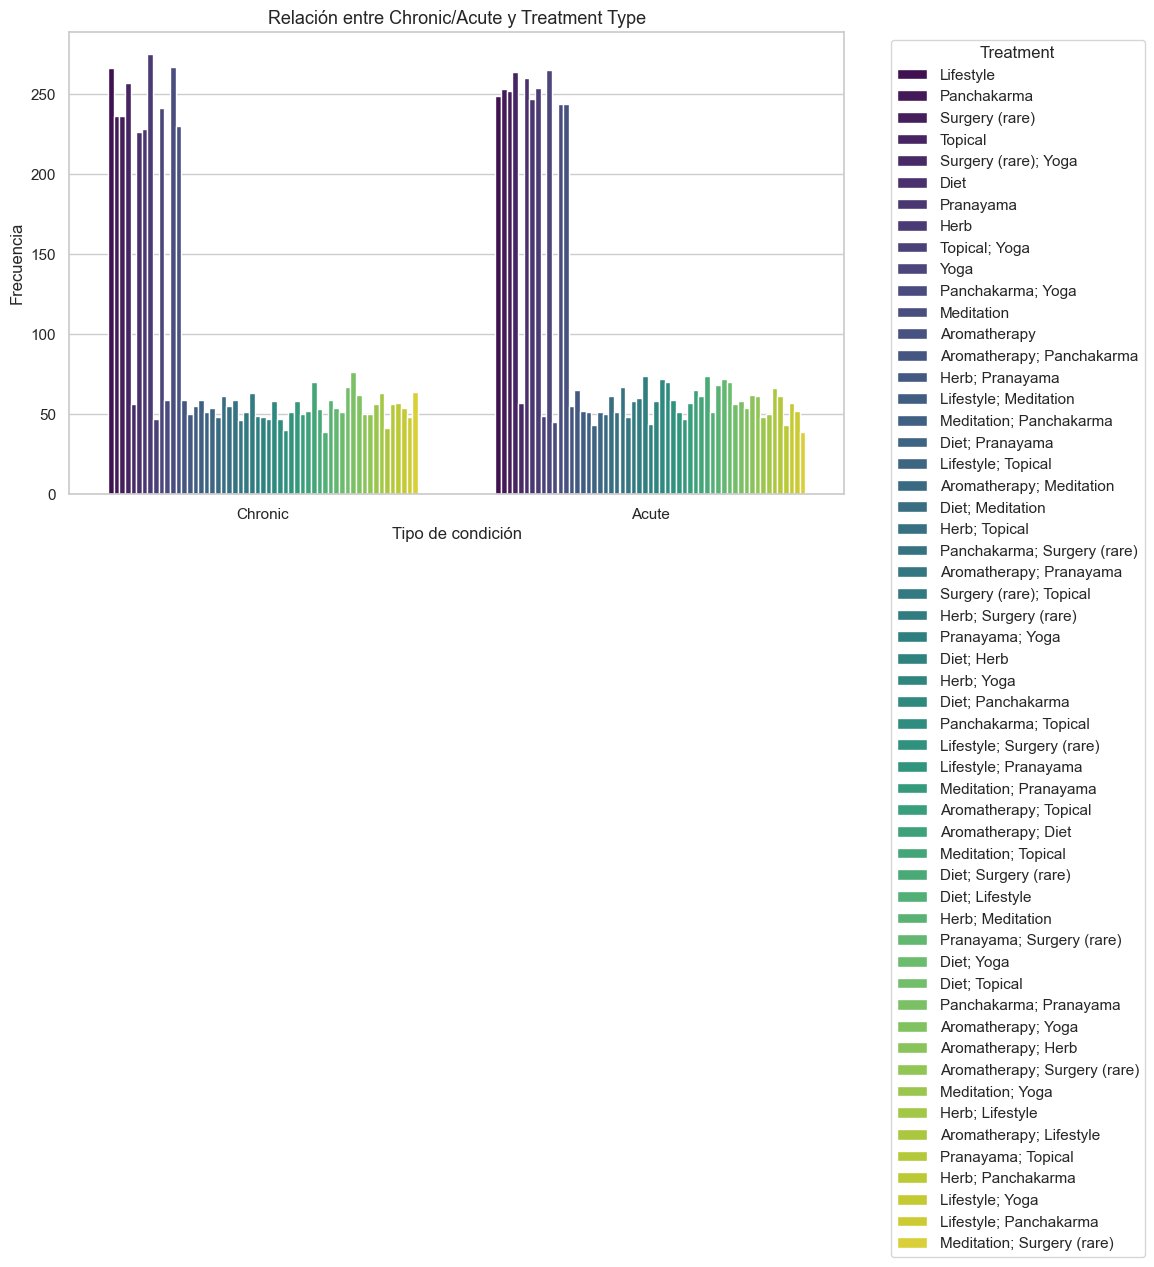

In [46]:
# RELACIÓN: Chronic vs Treatment

plt.figure(figsize=(10,6))
sns.countplot(
    data=df_cleaned,
    x='Chronic/Acute',
    hue='Treatment Type',
    palette='viridis'
)

plt.title('Relación entre Chronic/Acute y Treatment Type')
plt.xlabel('Tipo de condición')
plt.ylabel('Frecuencia')

plt.legend(title='Treatment', bbox_to_anchor=(1.05, 1))

plt.tight_layout()
plt.show()

El análisis muestra que no existe una relación claramente dominante entre el tipo de condición (crónica o aguda) y el tratamiento, lo cual sugiere que la variable objetivo depende de múltiples factores y no puede ser explicada por una sola característica.


### **5. Reducción de Clases (Feature Engineering de la Variable Objetivo)**

Durante el análisis exploratorio se identificó que la variable objetivo **“Treatment Type”** presentaba un alto número de categorías, muchas de ellas formadas por combinaciones de tratamientos o con diferencias semánticas mínimas.

#### **5.1 Problema Identificado**

El elevado número de clases generaba múltiples dificultades para el modelado:

- Aumento significativo de la complejidad del problema de clasificación  
- Alta similitud entre categorías, dificultando la separación entre clases  
- Presencia de clases con menor frecuencia, lo que introduce desbalance  
- Reducción en la capacidad de generalización de los modelos  

Este comportamiento fue confirmado en los primeros experimentos, donde los modelos mostraban bajo desempeño y alta confusión entre clases.

#### **5.2 Estrategia Aplicada**

Para abordar este problema, se implementó una estrategia de **agrupación de clases**, redefiniendo la variable objetivo en categorías más generales y representativas.

Se construyó un criterio de agrupación basado en el tipo de tratamiento, consolidando las categorías originales en cuatro grupos principales:

- **Medical:** tratamientos clínicos o farmacológicos  
- **Lifestyle:** intervenciones relacionadas con hábitos de vida (dieta, ejercicio, meditación)  
- **Herbal:** tratamientos basados en productos naturales o herbales  
- **Therapy:** terapias físicas o tratamientos tradicionales específicos  

#### **5.3 Implementación**

La transformación se realizó mediante una función de mapeo que asigna cada registro a una de las nuevas categorías, reduciendo la complejidad del problema.

#### **5.4 Resultados de la Transformación**

Después de aplicar la reducción de clases:

- El número de categorías se redujo significativamente  
- Se obtuvo una distribución más compacta y manejable  
- Se facilitó la capacidad de los modelos para identificar patrones  

Esta transformación permitió simplificar el problema sin perder el significado clínico de las categorías, mejorando la interpretabilidad y el desempeño del modelo.

In [47]:
# REDUCCIÓN DE CLASES
def map_treatment(t):
    t = t.lower()

    if 'diet' in t or 'yoga' in t or 'meditation' in t or 'exercise' in t:
        return 'Lifestyle'
    
    elif 'massage' in t or 'panchakarma' in t:
        return 'Therapy'
    
    elif 'herb' in t:
        return 'Herbal'
    
    else:
        return 'Medical'


df_cleaned['Treatment Type'] = df_cleaned['Treatment Type'].apply(map_treatment)

# RESULTADO

print(df_cleaned['Treatment Type'].value_counts())
print(f"\nNúmero de clases: {df_cleaned['Treatment Type'].nunique()}")

Treatment Type
Lifestyle    4172
Medical      3550
Therapy      1180
Herbal       1098
Name: count, dtype: int64

Número de clases: 4


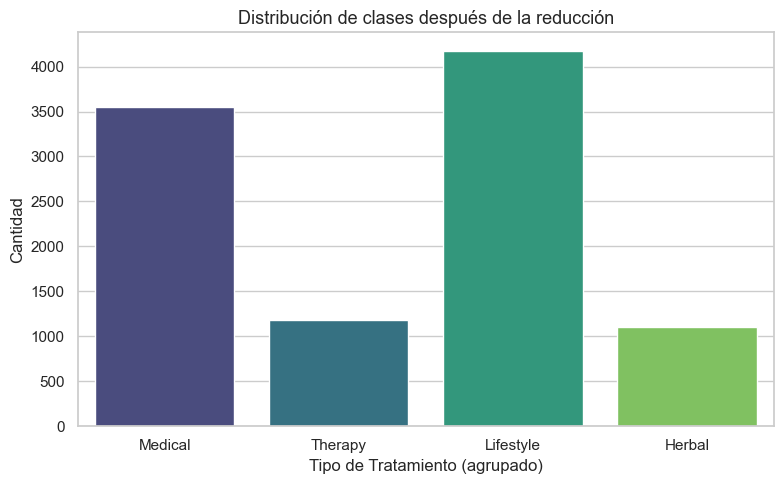

In [48]:
plt.figure(figsize=(8,5))
sns.countplot(data=df_cleaned, x='Treatment Type', palette='viridis')

plt.title('Distribución de clases después de la reducción')
plt.xlabel('Tipo de Tratamiento (agrupado)')
plt.ylabel('Cantidad')

plt.tight_layout()
plt.show()


### **6. Preparación y Transformación de Datos**

Una vez realizada la limpieza y reducción de la variable objetivo, se procedió a transformar las variables del dataset a un formato numérico adecuado para el entrenamiento de modelos de aprendizaje automático.

#### **6.1 Naturaleza de los datos**

El dataset está compuesto principalmente por variables categóricas y de texto, lo que requiere la aplicación de técnicas específicas para su conversión a representaciones numéricas.

La variable **“Symptoms”** contiene descripciones textuales de los síntomas, las cuales deben ser procesadas mediante técnicas de procesamiento de lenguaje natural. El resto de variables categóricas requieren ser codificadas para poder ser utilizadas por los modelos.

#### **6.2 Codificación de variables categóricas**

Se aplicó la técnica de **One-Hot Encoding** a las variables categóricas del dataset, transformando cada categoría en variables binarias independientes.

Las variables procesadas fueron:

- Body System  
- Chronic/Acute  
- Gender/Age Relevance  
- Seasonal Suitability  



#### **6.3 Procesamiento de texto mediante TF-IDF con n-gramas**

Para la variable **“Symptoms”**, se utilizó la técnica **TF-IDF (Term Frequency – Inverse Document Frequency)**.

A diferencia de una configuración básica basada únicamente en palabras individuales, se empleó una estrategia de **n-gramas (1,2)**, lo cual permite capturar tanto palabras individuales como combinaciones frecuentes de términos.

Esto permite representar expresiones más complejas como:
- “stomach pain”
- “high fever”

mejorando la capacidad del modelo para interpretar el contexto de los síntomas.

Además, se restringió el número de características a las más relevantes, reduciendo ruido en los datos y mejorando la eficiencia del modelo.

#### **6.4 Combinación de variables**

Una vez transformadas las variables categóricas y textuales, se combinaron todas las representaciones en una única matriz de características.

Se utilizaron estructuras de datos dispersas (*sparse matrices*) para optimizar el uso de memoria, dado que la representación TF-IDF genera una gran cantidad de variables.

#### **6.5 Reducción de dimensionalidad (Truncated SVD)**

Debido a la alta dimensionalidad generada por el proceso de vectorización de texto, se aplicó la técnica **Truncated SVD** para reducir el número de características.

Este proceso permite:

- Reducir el costo computacional  
- Eliminar redundancia en los datos  
- Mantener la mayor parte de la información relevante  

El resultado final es una representación más compacta y eficiente, adecuada para el entrenamiento de modelos de clasificación.

In [49]:
# VARIABLES X e Y

X_raw = df_cleaned.drop(columns=['Treatment Type'])
y = df_cleaned['Treatment Type']


# ONE-HOT ENCODING
from sklearn.preprocessing import OneHotEncoder

categorical_cols = [
    'Body System',
    'Chronic/Acute',
    'Gender/Age Relevance',
    'Seasonal Suitability'
]

ohe = OneHotEncoder(sparse_output=True, handle_unknown='ignore')
X_cat = ohe.fit_transform(X_raw[categorical_cols])


# TF-IDF (TEXT) CON BIGRAMAS
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=800,
    ngram_range=(1, 2),   # unigramas + bigramas
    min_df=2
)

X_text = tfidf.fit_transform(X_raw['Symptoms'])


# COMBINAR VARIABLES
from scipy.sparse import hstack

X_combined = hstack([X_text, X_cat])


# REDUCCIÓN DE DIMENSIONALIDAD (SVD)
from sklearn.decomposition import TruncatedSVD

svd = TruncatedSVD(n_components=100, random_state=42)
X_reduced = svd.fit_transform(X_combined)


# VERIFICACIÓN FINAL
print("✔ Transformación completada")
print(f"Dimensión final del dataset: {X_reduced.shape}")


✔ Transformación completada
Dimensión final del dataset: (10000, 100)


#### **Exportación del Dataset Procesado**

Con el objetivo de facilitar la reutilización del dataset y garantizar la reproducibilidad del proceso, se realizó la exportación de los datos transformados una vez completada la etapa de preparación.

Este archivo puede ser utilizado para futuros experimentos sin necesidad de repetir el proceso completo de transformación.

In [50]:

X_df = pd.DataFrame(X_reduced)

# Agregar el target
X_df['Target'] = y.reset_index(drop=True)

# Guardar archivo
X_df.to_csv('ayurveda_preprocessed.csv', index=False)

print("✔ Dataset procesado exportado correctamente")

import pandas as pd



✔ Dataset procesado exportado correctamente


### **7. División del Dataset**

El dataset fue dividido en dos partes:

- **80%** para entrenamiento  
- **20%** para prueba  

Esto permite entrenar el modelo con una parte de los datos y evaluar su desempeño con información no vista.

La variable objetivo fue transformada a valores numéricos mediante **Label Encoding**, ya que los modelos requieren datos en formato numérico.

Además, se utilizó el parámetro **stratify**, lo que garantiza que la proporción de clases sea similar tanto en el conjunto de entrenamiento como en el de prueba.

Esta división es importante para:

- Evaluar correctamente el modelo  
- Evitar sobreajuste  
- Obtener resultados más confiables  

In [51]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_encoded = le.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(
    X_reduced,
    y_encoded,
    test_size=0.20,
    random_state=42,
    stratify=y_encoded
)

print("✔ Split creado")

✔ Split creado


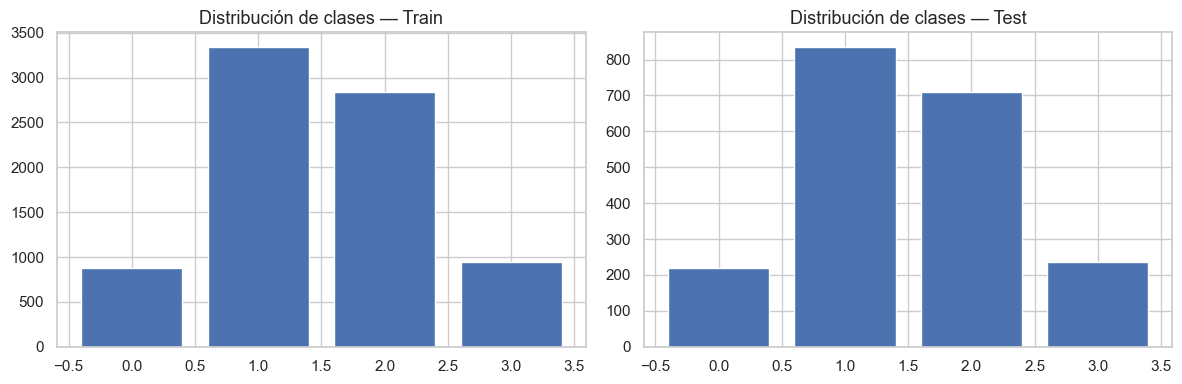

In [52]:
import pandas as pd
import matplotlib.pyplot as plt

train_counts = pd.Series(y_train).value_counts().sort_index()
test_counts = pd.Series(y_test).value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(12,4))

axes[0].bar(train_counts.index, train_counts.values)
axes[0].set_title('Distribución de clases — Train')

axes[1].bar(test_counts.index, test_counts.values)
axes[1].set_title('Distribución de clases — Test')

plt.tight_layout()
plt.show()

### **8. Modelos de Clasificación**

Con el dataset preparado, se procedió a entrenar distintos modelos de clasificación para evaluar su capacidad predictiva.

Inicialmente, se entrenaron los modelos utilizando los datos sin aplicar técnicas adicionales de balanceo o ajuste, con el objetivo de establecer una línea base de desempeño.

---

### **8.1 Regresión Multivariada (Logistic Regression)**

Se utilizó el modelo de regresión logística como primer enfoque, debido a su simplicidad y su capacidad para manejar problemas de clasificación multiclase.

Este modelo asume relaciones lineales entre las variables y la variable objetivo, por lo que sirve como punto de referencia inicial para comparar modelos más complejos.

GridSearchCV — Regresión Logística...

Fitting 5 folds for each of 4 candidates, totalling 20 fits

Mejores parámetros: {'C': 0.1, 'max_iter': 1000, 'solver': 'lbfgs'}
Mejor accuracy CV: 0.406125

RESULTADOS — Logistic Regression (GridSearch)
Accuracy: 0.4135

Classification Report:

              precision    recall  f1-score   support

           0       0.00      0.00      0.00       220
           1       0.42      0.81      0.55       834
           2       0.39      0.21      0.27       710
           3       0.00      0.00      0.00       236

    accuracy                           0.41      2000
   macro avg       0.20      0.26      0.21      2000
weighted avg       0.31      0.41      0.33      2000



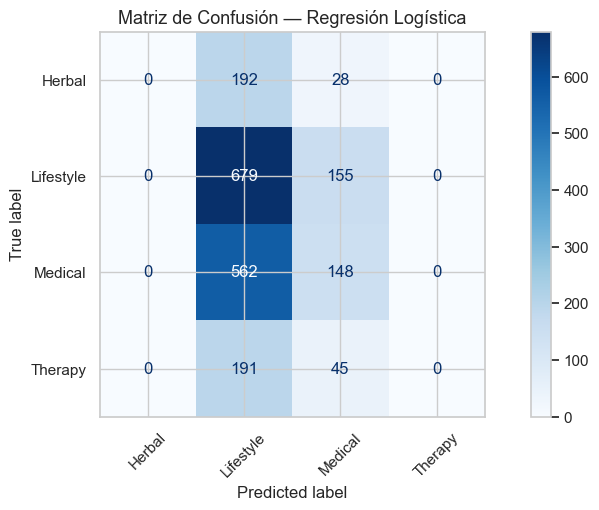

In [53]:

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV

print("GridSearchCV — Regresión Logística...\n")

param_grid_lr = {
    'C': [0.1, 0.5, 1, 2],
    'solver': ['lbfgs'],
    'max_iter': [1000]
}

lr = LogisticRegression(random_state=42)

gs_lr = GridSearchCV(
    estimator=lr,
    param_grid=param_grid_lr,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

gs_lr.fit(X_train, y_train)

print("\nMejores parámetros:", gs_lr.best_params_)
print("Mejor accuracy CV:", gs_lr.best_score_)


# EVALUACIÓN FINAL

y_pred_lr = gs_lr.best_estimator_.predict(X_test)

from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score, classification_report

acc_lr = accuracy_score(y_test, y_pred_lr)

print("\nRESULTADOS — Logistic Regression (GridSearch)")
print("Accuracy:", round(acc_lr, 4))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_lr))


# MATRIZ DE CONFUSIÓN
cm = confusion_matrix(y_test, y_pred_lr)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=le.classes_   # nombres reales de clases
)

disp.plot(cmap='Blues')
plt.title('Matriz de Confusión — Regresión Logística')
plt.xticks(rotation=45)

plt.show()


### **Resultados — Regresión Logística **

El modelo de regresión logística fue optimizado mediante el uso de GridSearchCV, evaluando distintas combinaciones de hiperparámetros mediante validación cruzada.

**Mejores parámetros:**
- C: 0.1  
- solver: lbfgs  
- max_iter: 1000  

**Accuracy (validación cruzada):** 0.406  
**Accuracy (test):** 0.4135  

#### **Classification Report**

| Clase | Precision | Recall | F1-score | Support |
|------|----------|-------|---------|---------|
| 0 | 0.00 | 0.00 | 0.00 | 220 |
| 1 | 0.42 | 0.81 | 0.55 | 834 |
| 2 | 0.39 | 0.21 | 0.27 | 710 |
| 3 | 0.00 | 0.00 | 0.00 | 236 |


**Accuracy global:** 0.41  
**F1-score macro:** 0.21  
**F1-score ponderado:** 0.33  

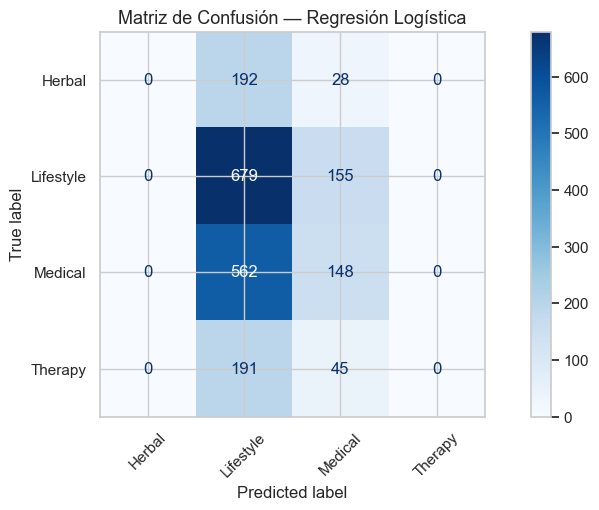

### **8.2 Árbol de Decisión**

Se entrenó un modelo de árbol de decisión como alternativa a la regresión logística, con el objetivo de capturar relaciones no lineales entre las variables.

A diferencia de los modelos lineales, los árboles de decisión dividen el espacio de datos en regiones, permitiendo una mayor flexibilidad para identificar patrones complejos.


GridSearchCV — Árbol de Decisión...

Fitting 5 folds for each of 36 candidates, totalling 180 fits

Mejores parámetros: {'max_depth': 5, 'min_samples_leaf': 2, 'min_samples_split': 2}
Mejor accuracy CV: 0.406375

RESULTADOS — Árbol de Decisión (GridSearch)
Accuracy: 0.4105

Classification Report:

              precision    recall  f1-score   support

           0       0.17      0.00      0.01       220
           1       0.42      0.91      0.57       834
           2       0.38      0.09      0.14       710
           3       0.11      0.00      0.01       236

    accuracy                           0.41      2000
   macro avg       0.27      0.25      0.18      2000
weighted avg       0.34      0.41      0.29      2000



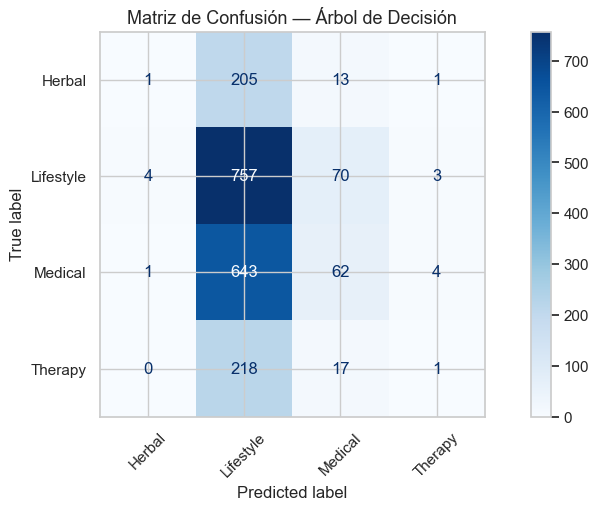

In [54]:
from sklearn.tree import DecisionTreeClassifier

print("GridSearchCV — Árbol de Decisión...\n")

param_grid_dt = {
    'max_depth': [5, 10, 15, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

dt = DecisionTreeClassifier(random_state=42)

gs_dt = GridSearchCV(
    estimator=dt,
    param_grid=param_grid_dt,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

gs_dt.fit(X_train, y_train)

print("\nMejores parámetros:", gs_dt.best_params_)
print("Mejor accuracy CV:", gs_dt.best_score_)


# EVALUACIÓN FINAL
y_pred_dt = gs_dt.best_estimator_.predict(X_test)

from sklearn.metrics import accuracy_score, classification_report

acc_dt = accuracy_score(y_test, y_pred_dt)

print("\nRESULTADOS — Árbol de Decisión (GridSearch)")
print("Accuracy:", round(acc_dt, 4))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_dt))


# MATRIZ DE CONFUSIÓN
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred_dt)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=le.classes_
)

disp.plot(cmap='Blues')
plt.title('Matriz de Confusión — Árbol de Decisión')
plt.xticks(rotation=45)

plt.show()

### Resultados — Árbol de Decisión 

**Mejores parámetros:**
- max_depth: 5  
- min_samples_leaf: 2  
- min_samples_split: 2  

**Accuracy (validación cruzada):** 0.406  
**Accuracy (test):** 0.4105  

#### **Classification Report**

| Clase | Precision | Recall | F1-score | Support |
|------|----------|-------|---------|---------|
| 0 | 0.17 | 0.00 | 0.01 | 220 |
| 1 | 0.42 | 0.91 | 0.57 | 834 |
| 2 | 0.38 | 0.09 | 0.14 | 710 |
| 3 | 0.11 | 0.00 | 0.01 | 236 |

---

**Accuracy global:** 0.41  
**F1-score macro:** 0.18  
**F1-score ponderado:** 0.29  

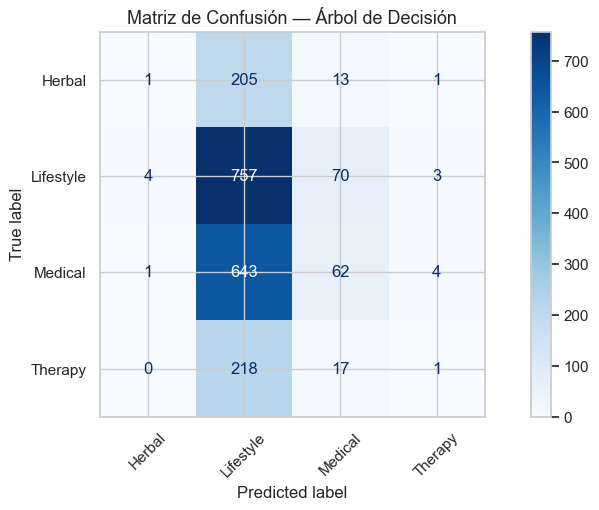

### **8.3 Random Forest**

Se utilizó el modelo Random Forest, el cual consiste en un ensamble de múltiples árboles de decisión.

A diferencia de un solo árbol, Random Forest combina múltiples modelos entrenados sobre diferentes subconjuntos de datos, reduciendo el sobreajuste y mejorando la capacidad de generalización.

Este modelo es capaz de capturar relaciones no lineales de forma más robusta, por lo que se espera un mejor desempeño en comparación con los modelos anteriores.

GridSearchCV — Random Forest...

Fitting 5 folds for each of 24 candidates, totalling 120 fits

Mejores parámetros: {'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 300}
Mejor accuracy CV: 0.397125

RESULTADOS — Random Forest
Accuracy: 0.3955

Classification Report:

              precision    recall  f1-score   support

           0       0.00      0.00      0.00       220
           1       0.41      0.72      0.52       834
           2       0.36      0.26      0.30       710
           3       0.00      0.00      0.00       236

    accuracy                           0.40      2000
   macro avg       0.19      0.25      0.21      2000
weighted avg       0.30      0.40      0.33      2000



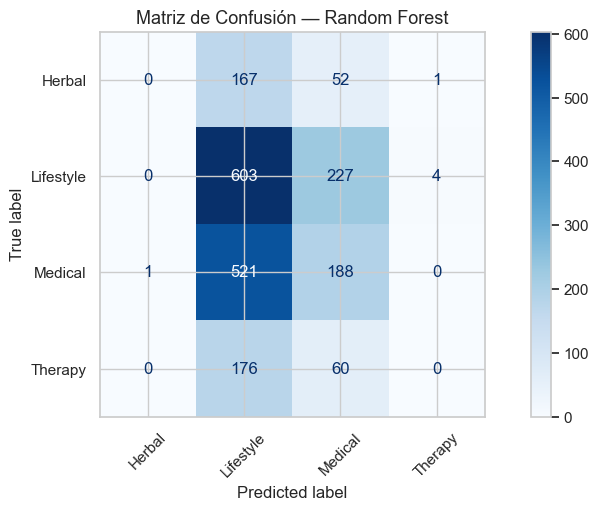

In [55]:

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

print("GridSearchCV — Random Forest...\n")

param_grid_rf = {
    'n_estimators': [200, 300],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

rf = RandomForestClassifier(
    random_state=42,
    n_jobs=-1
)

gs_rf = GridSearchCV(
    estimator=rf,
    param_grid=param_grid_rf,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

gs_rf.fit(X_train, y_train)

# RESULTADOS
print("\nMejores parámetros:", gs_rf.best_params_)
print("Mejor accuracy CV:", gs_rf.best_score_)


# EVALUACIÓN FINAL
y_pred_rf = gs_rf.best_estimator_.predict(X_test)

from sklearn.metrics import accuracy_score, classification_report

acc_rf = accuracy_score(y_test, y_pred_rf)

print("\nRESULTADOS — Random Forest")
print("Accuracy:", round(acc_rf, 4))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_rf))

# MATRIZ DE CONFUSIÓN
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred_rf)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=le.classes_
)

disp.plot(cmap='Blues')
plt.title('Matriz de Confusión — Random Forest')
plt.xticks(rotation=45)

plt.show()


### **Resultados — Random Forest **

El modelo Random Forest fue optimizado mediante GridSearchCV, evaluando múltiples combinaciones de hiperparámetros mediante validación cruzada.

**Mejores parámetros:**
- max_depth: 10  
- min_samples_leaf: 1  
- min_samples_split: 5  
- n_estimators: 300  

**Accuracy (validación cruzada):** 0.397  
**Accuracy (test):** 0.3955  

#### **Classification Report**

| Clase | Precision | Recall | F1-score | Support |
|------|----------|-------|---------|---------|
| 0 | 0.00 | 0.00 | 0.00 | 220 |
| 1 | 0.41 | 0.72 | 0.52 | 834 |
| 2 | 0.36 | 0.26 | 0.30 | 710 |
| 3 | 0.00 | 0.00 | 0.00 | 236 |

---

**Accuracy global:** 0.40  
**F1-score macro:** 0.21  
**F1-score ponderado:** 0.33  

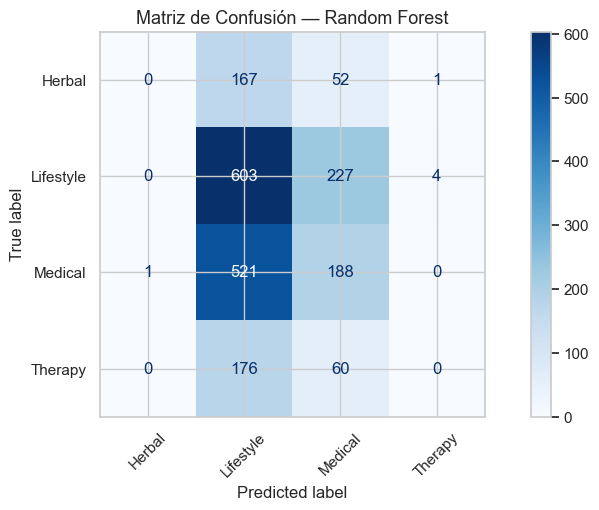

El modelo Random Forest, con GridSearchCV, presenta un desempeño estable con una buena correspondencia entre la validación cruzada y el conjunto de prueba.

Sin embargo, los resultados muestran que no se obtienen mejoras significativas respecto a modelos más simples como la regresión logística.

El análisis del classification report indica que el modelo continúa presentando un fuerte sesgo hacia la clase mayoritaria, sin lograr identificar correctamente las clases minoritarias.

Este comportamiento evidencia que la limitación principal del problema no está en la elección del modelo, sino en la naturaleza del dataset, caracterizada por desbalance y solapamiento entre clases.


### **8.4 Redes Neuronales (MLP)**

Se implementó un modelo de red neuronal multicapa (MLP), el cual es capaz de capturar relaciones complejas y no lineales entre las variables.

Se espera que este modelo tenga un mejor desempeño que los modelos lineales y los árboles individuales, debido a su mayor capacidad de aprendizaje.


GridSearchCV — MLP (búsqueda amplia)...

Fitting 5 folds for each of 45 candidates, totalling 225 fits

Mejores parámetros: {'alpha': 0.001, 'hidden_layer_sizes': (100, 50), 'learning_rate_init': 0.01}
Mejor accuracy CV: 0.38225000000000003

RESULTADOS — MLP (GridSearch)
Accuracy: 0.359

Classification Report:

              precision    recall  f1-score   support

           0       0.03      0.00      0.01       220
           1       0.39      0.54      0.46       834
           2       0.33      0.37      0.35       710
           3       0.11      0.02      0.03       236

    accuracy                           0.36      2000
   macro avg       0.22      0.23      0.21      2000
weighted avg       0.30      0.36      0.32      2000



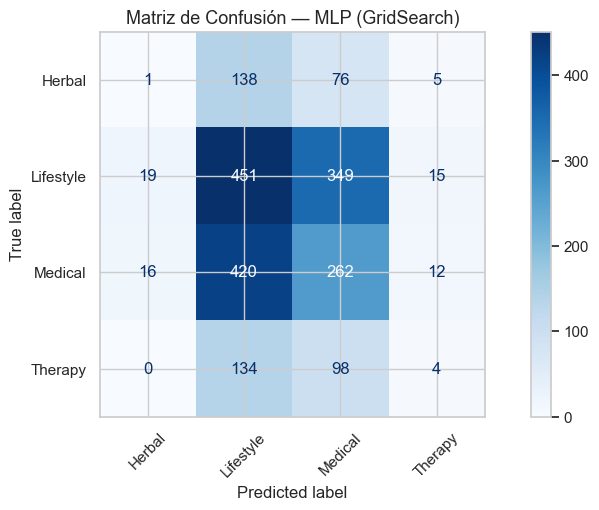

In [57]:
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import GridSearchCV

print("GridSearchCV — MLP (búsqueda amplia)...\n")

param_grid_mlp = {
    'hidden_layer_sizes': [
        (50,),
        (100,),
        (150,),
        (50,50),
        (100,50)
    ],
    'alpha': [0.0001, 0.001, 0.01],     # regularización
    'learning_rate_init': [0.001, 0.005, 0.01]
}

mlp = MLPClassifier(
    max_iter=400,     
    random_state=42
)

gs_mlp = GridSearchCV(
    estimator=mlp,
    param_grid=param_grid_mlp,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

gs_mlp.fit(X_train, y_train)


# RESULTADOS
print("\nMejores parámetros:", gs_mlp.best_params_)
print("Mejor accuracy CV:", gs_mlp.best_score_)


# EVALUACIÓN FINAL
y_pred_mlp = gs_mlp.best_estimator_.predict(X_test)

from sklearn.metrics import accuracy_score, classification_report

acc_mlp = accuracy_score(y_test, y_pred_mlp)

print("\nRESULTADOS — MLP (GridSearch)")
print("Accuracy:", round(acc_mlp, 4))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_mlp))

# MATRIZ DE CONFUSIÓN
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred_mlp)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=le.classes_
)

disp.plot(cmap='Blues')
plt.title('Matriz de Confusión — MLP (GridSearch)')
plt.xticks(rotation=45)

plt.show()

### **Resultados — Red Neuronal (MLP)**

El modelo de red neuronal multicapa (MLP) fue optimizado mediante GridSearchCV, evaluando múltiples configuraciones de arquitectura y parámetros de entrenamiento.

**Mejores parámetros:**
- hidden_layer_sizes: (100, 50)  
- alpha: 0.001  
- learning_rate_init: 0.01  

**Accuracy (validación cruzada):** 0.382  
**Accuracy (test):** 0.359  

#### **Classification Report**

| Clase | Precision | Recall | F1-score | Support |
|------|----------|-------|---------|---------|
| 0 | 0.03 | 0.00 | 0.01 | 220 |
| 1 | 0.39 | 0.54 | 0.46 | 834 |
| 2 | 0.33 | 0.37 | 0.35 | 710 |
| 3 | 0.11 | 0.02 | 0.03 | 236 |

---

**Accuracy global:** 0.36  
**F1-score macro:** 0.21  
**F1-score ponderado:** 0.32  

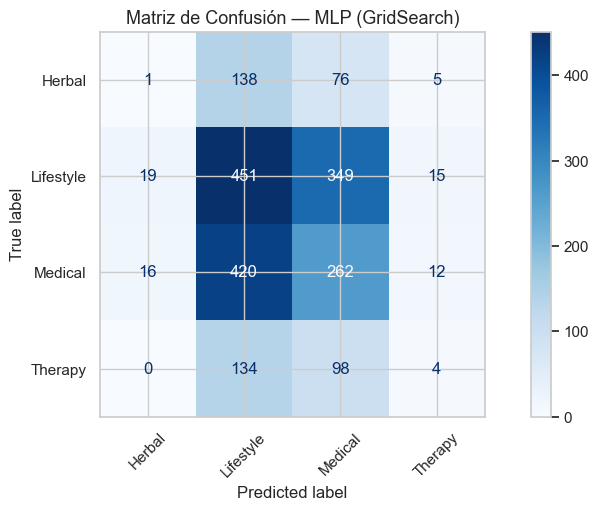

El modelo MLP optimizado mediante GridSearchCV presenta un desempeño inferior al de modelos más simples como la regresión logística y los árboles de decisión.

A pesar de explorar múltiples configuraciones de arquitectura y parámetros de entrenamiento, los resultados obtenidos no muestran mejoras significativas, e incluso presentan una disminución en la accuracy.

Este comportamiento indica que el incremento en la complejidad del modelo no se traduce en un mejor desempeño, lo que sugiere que las limitaciones del problema están asociadas principalmente a la estructura del dataset.

Particularmente, el desbalance de clases y el solapamiento entre categorías afectan la capacidad de los modelos para generalizar correctamente.

### **8.5 Red Neuronal Profunda (DNN)**

Se implementó una red neuronal profunda (Deep Neural Network), con múltiples capas ocultas, con el objetivo de aumentar la capacidad del modelo para aprender representaciones complejas de los datos.

A diferencia del MLP básico, esta configuración permite capturar relaciones más profundas entre las variables, aunque también incrementa la complejidad del entrenamiento.

In [58]:
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import GridSearchCV

print("GridSearchCV — DNN...\n")

param_grid_dnn = {
    'hidden_layer_sizes': [
        (100, 100),
        (150, 100),
        (100, 100, 50)   # 🔥 más profunda
    ],
    'alpha': [0.0001, 0.001],
    'learning_rate_init': [0.001, 0.005]
}

dnn = MLPClassifier(
    max_iter=400,
    random_state=42
)

gs_dnn = GridSearchCV(
    estimator=dnn,
    param_grid=param_grid_dnn,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

gs_dnn.fit(X_train, y_train)


# RESULTADOS
print("\nMejores parámetros:", gs_dnn.best_params_)
print("Mejor accuracy CV:", gs_dnn.best_score_)


# EVALUACIÓN FINAL
y_pred_dnn = gs_dnn.best_estimator_.predict(X_test)

from sklearn.metrics import accuracy_score, classification_report

acc_dnn = accuracy_score(y_test, y_pred_dnn)

print("\nRESULTADOS — DNN")
print("Accuracy:", round(acc_dnn, 4))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_dnn))

# MATRIZ DE CONFUSIÓN

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

def plot_confusion(y_test, y_pred, title):
    cm = confusion_matrix(y_test, y_pred)

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=le.classes_
    )

    disp.plot(cmap='Blues')
    plt.title(title)
    plt.xticks(rotation=45)

    plt.show()

GridSearchCV — DNN...

Fitting 5 folds for each of 12 candidates, totalling 60 fits

Mejores parámetros: {'alpha': 0.001, 'hidden_layer_sizes': (150, 100), 'learning_rate_init': 0.005}
Mejor accuracy CV: 0.380125

RESULTADOS — DNN
Accuracy: 0.3565

Classification Report:

              precision    recall  f1-score   support

           0       0.04      0.01      0.02       220
           1       0.40      0.49      0.44       834
           2       0.34      0.42      0.38       710
           3       0.10      0.02      0.03       236

    accuracy                           0.36      2000
   macro avg       0.22      0.23      0.22      2000
weighted avg       0.30      0.36      0.32      2000



### **Resultados — Red Neuronal Profunda (DNN)**


**Mejores parámetros:**
- hidden_layer_sizes: (150, 100)  
- alpha: 0.001  
- learning_rate_init: 0.005  

**Accuracy (validación cruzada):** 0.380  
**Accuracy (test):** 0.3565  

#### **Classification Report**

| Clase | Precision | Recall | F1-score | Support |
|------|----------|-------|---------|---------|
| 0 | 0.04 | 0.01 | 0.02 | 220 |
| 1 | 0.40 | 0.49 | 0.44 | 834 |
| 2 | 0.34 | 0.42 | 0.38 | 710 |
| 3 | 0.10 | 0.02 | 0.03 | 236 |

---

**Accuracy global:** 0.36  
**F1-score macro:** 0.22  
**F1-score ponderado:** 0.32  

El modelo de red neuronal profunda (DNN) no presenta mejoras significativas respecto a los modelos evaluados previamente, a pesar de su mayor complejidad.

Los resultados muestran una disminución en la accuracy en comparación con modelos más simples, como la regresión logística o los árboles de decisión.

Este comportamiento indica que incrementar la profundidad y capacidad del modelo no es suficiente para mejorar el desempeño, sugiriendo que las limitaciones del problema están asociadas principalmente a la estructura del dataset.

En particular, el desbalance entre clases y el solapamiento entre categorías afectan la capacidad de generalización del modelo.

### **Conclusiones de los Modelos Base**

Tras la implementación y evaluación de distintos modelos de clasificación, incluyendo regresión logística, árboles de decisión, Random Forest y redes neuronales (MLP y DNN), se obtuvieron los siguientes hallazgos:

#### **1. Comparación General de Desempeño**

Los modelos evaluados presentan valores de accuracy relativamente cercanos, situándose en un rango aproximado entre 0.35 y 0.41. Aunque algunos modelos más simples, como la regresión logística, lograron los mejores resultados en términos de accuracy, las diferencias entre modelos no son significativamente amplias.

#### **2. Comportamiento por Clases**

El análisis de los classification reports y las matrices de confusión evidencia un patrón común en todos los modelos:

- Fuerte desempeño en la clase mayoritaria  
- Bajo rendimiento en las clases minoritarias  
- Dificultad para lograr una clasificación equilibrada  

En particular, las clases menos representadas presentan valores muy bajos de recall y F1-score, lo que indica que los modelos no logran identificarlas correctamente.

#### **3. Impacto de la Complejidad del Modelo**

A pesar de evaluar modelos con diferentes niveles de complejidad:

- Los modelos lineales presentan limitaciones esperadas  
- Los modelos basados en árboles mejoran parcialmente la representación  
- Los modelos ensamble (Random Forest) no generan mejoras significativas  
- Las redes neuronales (MLP y DNN), incluso tras la optimización, no logran superar a modelos más simples  

Esto demuestra que aumentar la complejidad del modelo no se traduce necesariamente en una mejora del desempeño.

#### **4. Resultados de la Optimización (GridSearchCV)**

El uso de GridSearchCV permitió encontrar configuraciones óptimas de hiperparámetros para varios modelos. Sin embargo, las mejoras obtenidas fueron marginales, lo que indica que el problema no reside en la configuración de los modelos, sino en otros factores subyacentes.

#### **5. Limitaciones Identificadas**

Los resultados obtenidos sugieren que el desempeño de los modelos está condicionado principalmente por:

- El desbalance existente entre clases  
- El solapamiento entre categorías  
- La complejidad semántica de los datos  

#### **Conclusión General**

En conjunto, los resultados indican que ninguno de los modelos evaluados logra un desempeño satisfactorio en todas las clases. Esto sugiere que las limitaciones del problema no están asociadas al tipo de modelo utilizado, sino a la naturaleza del dataset.

Por lo tanto, se hace necesario aplicar estrategias adicionales orientadas al tratamiento de los datos, como técnicas de balanceo y generación de muestras, con el fin de mejorar el rendimiento del sistema de clasificación.